In [1]:
!pip install gutenbergpy
# !pip install "megablocks[gg]"

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 39.4 MB/s eta 0:00:00
  Created wheel for httpsproxy-urllib2: filename=httpsproxy_urllib2-1.0-py3-none-any.whl size=29251 sha256=843e978b52a98f11bdf77a22d1f4a7e221a0b211242eb15193c0e994ed71e15f
  Stored in directory: /root/.cache/pip/wheels/c6/c5/98/dd27835c8319362f1cef163409f43df38d54f084500fad428c
Successfully built httpsproxy-urllib2


In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
# import megablocks.ops as ops
# from megablocks.layers import mpu
# import stk
import tiktoken as tk
import matplotlib.pyplot as plt
import numpy as np
import pprint
import gutenbergpy.textget
import random

In [3]:
tokenizer = tk.get_encoding("gpt2")

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [ ]:
a = torch.tensor([[1,2]])
b = torch.tensor([[3],[4]])

a.shape, b.shape

(torch.Size([1, 2]), torch.Size([2, 1]))

In [ ]:
torch.sum(a,a) # sum is not element-wise op it reduction op

TypeError: sum() received an invalid combination of arguments - got (Tensor, Tensor), but expected one of:
 * (Tensor input, *, torch.dtype dtype = None)
 * (Tensor input, tuple of ints dim, bool keepdim = False, *, torch.dtype dtype = None, Tensor out = None)
 * (Tensor input, tuple of names dim, bool keepdim = False, *, torch.dtype dtype = None, Tensor out = None)


In [ ]:
a+b

tensor([[4, 5],
        [5, 6]])

# **Utils**

In [5]:
def text_to_token_ids(text, tokenizer):
  encoded = tokenizer.encode(text)
  encoded_tensor = torch.tensor(encoded).unsqueeze(0)
  return encoded_tensor

def token_ids_to_text(tokens, tokenizer):
  token_list = tokens.squeeze(0).tolist()
  decoded = tokenizer.decode(token_list)
  return decoded

In [6]:
class GPTDataset(Dataset):
  def __init__(self, text, tokenizer, max_length, stride):
    self.inputs = []
    self.targets = []

    encoded_text = tokenizer.encode(text)

    for i in range(0,len(encoded_text) - max_length, stride):
      input = encoded_text[i:i+max_length]
      target = encoded_text[i+1:i+max_length+1]

      self.inputs.append(torch.tensor(input))
      self.targets.append(torch.tensor(target))

  def __len__(self):
    return len(self.inputs)

  def __getitem__(self, index):
    return self.inputs[index], self.targets[index]

In [7]:
def download_dataset(n_books=100):
    # IDs are roughly between 1 and 70,000
    # We'll pick random IDs; note: not all IDs exist or are English
    book_ids = random.sample(range(1, 60000), n_books * 2)
    downloaded_texts = []

    for b_id in book_ids:
        try:
            # 1. Get raw text
            raw_text = gutenbergpy.textget.get_text_by_id(b_id)
            # 2. Strip Gutenberg headers/footers (CRITICAL for LLMs)
            clean_text = gutenbergpy.textget.strip_headers(raw_text)

            downloaded_texts.append(clean_text.decode('utf-8'))
            print(f"Downloaded book {b_id}")

            if len(downloaded_texts) >= n_books:
                break
        except:
            continue # Skip IDs that aren't available in text format

    return downloaded_texts

In [8]:
random.seed(10)
texts = download_dataset(n_books=15)
shuffled_texts = random.sample(texts, len(texts))
train_texts_list = shuffled_texts[:13]
val_texts_list = shuffled_texts[13:]

train_texts = tokenizer.decode([tokenizer.eot_token])[0].join(train_texts_list)
val_texts = tokenizer.decode([tokenizer.eot_token])[0].join(val_texts_list)

Downloaded book 37448
Downloaded book 2136
Downloaded book 28108
Downloaded book 31626
Downloaded book 37886
Downloaded book 973
Downloaded book 13507
Downloaded book 30316
Downloaded book 53302
Downloaded book 32198
Downloaded book 53975
Downloaded book 18188
Downloaded book 42826
Downloaded book 53125
Downloaded book 10501


In [9]:
print(texts[0])











[Illustration: BRINKER BRINKER in footprints]




     _A man may be a scoundrel, a crook, a high-phased confidence man,
     and still work toward a great dream which will be worth far more
     than the momentary damage his swindles cost._




_Comet's Burial_

_by_ RAYMOND Z. GALLUN


Outside Tycho Station on the Moon, Jess Brinker showed Arne Copeland the
odd footprints made in the dust by explorers from Mars, fifty million
years ago. A man-made cover of clear plastic now kept them from being
trampled.

"Who hasn't heard about such prints?" Copeland growled laconically.
"There's no air or weather here to rub them out--even in eternity.
Thanks for showing a fresh-arrived greenhorn around..."

Copeland was nineteen, tough, willing to learn, but wary. His wide mouth
was usually sullen, his grey eyes a little narrowed in a face that
didn't have to be so grim. Back in Iowa he had a girl. Frances. But love
had to wait, for he needed the Moon the way Peary had once needed the
No

In [10]:
print(f"Tokens in train set: {len(tokenizer.encode(train_texts))}")
print(f"Tokens in val set: {len(tokenizer.encode(val_texts))}")

Tokens in train set: 768464
Tokens in val set: 81370


In [11]:
white_space = np.array(tokenizer.encode(train_texts))
idx = np.argwhere(white_space == 220)
idx.shape

(13018, 1)

In [12]:
train_dataset = GPTDataset(train_texts, tokenizer, max_length=256, stride=256)
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, drop_last=True, num_workers=0)

val_dataset = GPTDataset(val_texts, tokenizer, max_length=256, stride=256)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False, drop_last=True, num_workers=0)

In [13]:
for i, (x,y) in enumerate(train_loader):
  print(x.shape, y.shape)
  break

torch.Size([2, 256]) torch.Size([2, 256])


In [14]:
for x,y in val_loader:
  print(x.shape, y.shape)
  break

torch.Size([2, 256]) torch.Size([2, 256])


In [15]:
def ce_batch_loss_calc(input_batch, target_batch, model, device):
  """
  ARGS
  input_batch: torch.tensor 2-D
  target_batch: torch.tensor 2-D
  model: GPTModel
  device: torch.device - 'cuda' or 'cpu'

  calculates cross-entropy loss for a batch
  """
  input_batch = input_batch.to(device)
  target_batch = target_batch.to(device)
  logits_batch = model(input_batch)
  loss = torch.nn.functional.cross_entropy(logits_batch.flatten(0, 1), target_batch.flatten())

  return loss

In [16]:
def calc_loss_dense_dataloader(loader, model, device, num_batches=None):
  """
  ARGS
  loader: dataloader
  model: GPTModel
  device: torch.device - 'cuda' or 'cpu'
  num_batches: integer

  calculates mean cross entropy loss across all the batches of the dataloader
  """
  total_loss = 0
  if len(loader) == 0:
    return float('nan')
  elif num_batches is None:
    num_batches = len(loader)
  elif num_batches < 0:
    num_batches = float('nan')
  else:
    num_batches = min(num_batches, len(loader))

  for i, (x, y) in enumerate(loader):
    if i < num_batches:
      loss = ce_batch_loss_calc(x, y, model, device)
      total_loss += loss
    else:
      break

  return total_loss/num_batches

In [17]:
def ce_batch_loss_without_load_bal_calc(input_batch, target_batch, model, device):
  """
  ARGS
  input_batch: torch.tensor 2-D
  target_batch: torch.tensor 2-D
  model: GPTModel
  device: torch.device - 'cuda' or 'cpu'

  calculates cross-entropy loss for a batch
  """
  input_batch = input_batch.to(device)
  target_batch = target_batch.to(device)
  logits_batch, _, f_vector_plot = model(input_batch)
  loss = torch.nn.functional.cross_entropy(logits_batch.flatten(0, 1), target_batch.flatten())

  return loss, f_vector_plot

In [18]:
def calc_loss_moe_dataloader(loader, model, device, num_batches=None):
  """
  ARGS
  loader: dataloader
  model: GPTModel
  device: torch.device - 'cuda' or 'cpu'
  num_batches: integer

  calculates mean cross entropy loss across all the batches of the dataloader
  """
  total_loss = 0
  if len(loader) == 0:
    return float('nan')
  elif num_batches is None:
    num_batches = len(loader)
  elif num_batches < 0:
    num_batches = float('nan')
  else:
    num_batches = min(num_batches, len(loader))

  for i, (x, y) in enumerate(loader):
    if i < num_batches:
      loss, _ = ce_batch_loss_without_load_bal_calc(x, y, model, device)
      total_loss += loss
    else:
      break

  return total_loss/num_batches

In [19]:
def ce_batch_load_bal_loss_calc(input_batch, target_batch, model, device):
  """
  ARGS
  input_batch: torch.tensor 2-D
  target_batch: torch.tensor 2-D
  model: GPTModel
  device: torch.device - 'cuda' or 'cpu'

  calculates cross-entropy + load_bal loss for a batch
  """
  input_batch = input_batch.to(device)
  target_batch = target_batch.to(device)
  logits_batch, total_lb_loss, f_vector_plot = model(input_batch)
  loss = torch.nn.functional.cross_entropy(logits_batch.flatten(0, 1), target_batch.flatten()) + 1e-2 * total_lb_loss

  return loss, f_vector_plot

In [20]:
def generate_text_tokens(model, inp_tokens, max_tokens, context_size):
  for _ in range(max_tokens):
    cropped_tokens = inp_tokens[:,-context_size:]
    with torch.no_grad():
      logits, _, _ = model(cropped_tokens)

    logits = logits[:,-1,:]
    prob = torch.softmax(logits, dim=-1)
    token_id = torch.argmax(prob, dim=-1, keepdim=True)
    inp_tokens = torch.cat((inp_tokens, token_id), dim=1)

  return inp_tokens

In [21]:
def generate_text_tokens_dense(model, inp_tokens, max_tokens, context_size):
  for _ in range(max_tokens):
    cropped_tokens = inp_tokens[:,-context_size:]
    with torch.no_grad():
      logits = model(cropped_tokens)

    logits = logits[:,-1,:]
    prob = torch.softmax(logits, dim=-1)
    token_id = torch.argmax(prob, dim=-1, keepdim=True)
    inp_tokens = torch.cat((inp_tokens, token_id), dim=1)

  return inp_tokens

In [22]:
def generate_and_print_sample(model, start_context, tokenizer, device):
  model.eval()
  context_size = model.trf_blocks[0].mha.mask.shape[0] ##model.pos_emb.shape[0]
  encoded_text = text_to_token_ids(start_context, tokenizer).to(device)
  with torch.no_grad():
    op_tokens = generate_text_tokens(model, encoded_text, max_tokens=50, context_size=context_size)
  decoded_text = token_ids_to_text(op_tokens, tokenizer)

  print(decoded_text.replace('\n',' '))
  model.train()

In [23]:
def generate_and_print_sample_dense(model, start_context, tokenizer, device):
  model.eval()
  context_size = model.trf_blocks[0].mha.mask.shape[0] ##model.pos_emb.shape[0]
  encoded_text = text_to_token_ids(start_context, tokenizer).to(device)
  with torch.no_grad():
    op_tokens = generate_text_tokens_dense(model, encoded_text, max_tokens=50, context_size=context_size)
  decoded_text = token_ids_to_text(op_tokens, tokenizer)

  print(decoded_text.replace('\n',' '))
  model.train()

In [24]:
def evaluate_model_dense(model, train_loader, val_loader, device, eval_iter=None):
  model.eval()
  with torch.no_grad():
    train_loss = calc_loss_dense_dataloader(train_loader, model, device, eval_iter)
    val_loss = calc_loss_dense_dataloader(val_loader, model, device, eval_iter)
  model.train()

  return train_loss, val_loss

In [25]:
def evaluate_model_moe(model, train_loader, val_loader, device, eval_iter=None):
  model.eval()
  with torch.no_grad():
    train_loss = calc_loss_moe_dataloader(train_loader, model, device, eval_iter)
    val_loss = calc_loss_moe_dataloader(val_loader, model, device, eval_iter)
  model.train()

  return train_loss, val_loss

In [26]:
def train_model_simple(model, train_loader, val_loader, device, optimizer, epochs, eval_freq, eval_iter, start_context, tokenizer):
  train_loss_arr, val_loss_arr, track_tokens_seen = [], [], []
  global_step, tokens_seen = -1, 0

  for epoch in range(epochs):
    model.train()
    for x, y in train_loader:
      model.zero_grad()
      train_loss = ce_batch_loss_calc(x, y, model, device)
      train_loss.backward()
      optimizer.step()
      tokens_seen += x.numel()
      global_step += 1

      if global_step % eval_freq == 0:
        train_loss, val_loss = evaluate_model_dense(model, train_loader, val_loader, device, eval_iter)
        train_loss_arr.append(train_loss)
        val_loss_arr.append(val_loss)
        track_tokens_seen.append(tokens_seen)
        print(f'Train loss after epoch {epoch} (Step: {global_step}): {train_loss:.3f}')
        print(f'Val loss after epoch {epoch} (Step: {global_step}): {val_loss:.3f}')
        print(f'Number of tokens seen after epoch {epoch} (Step: {global_step}): {tokens_seen}')

    generate_and_print_sample_dense(model, start_context, tokenizer, device)

  return train_loss_arr, val_loss_arr, track_tokens_seen

In [27]:
def train_model_without_load_bal(model, train_loader, val_loader, device, optimizer, epochs, eval_freq, eval_iter, start_context, tokenizer):
  train_loss_arr, val_loss_arr, track_tokens_seen, fract_tokens_per_expert_list = [], [], [], []
  global_step, tokens_seen = -1, 0

  for epoch in range(epochs):
    model.train()
    for x, y in train_loader:
      model.zero_grad()
      train_loss, f_vector_plot = ce_batch_loss_without_load_bal_calc(x, y, model, device)
      train_loss.backward()
      optimizer.step()
      tokens_seen += x.numel()
      global_step += 1
      fract_tokens_per_expert_list.append(f_vector_plot)

      if global_step % eval_freq == 0:
        train_loss, val_loss = evaluate_model_moe(model, train_loader, val_loader, device, eval_iter)
        train_loss_arr.append(train_loss)
        val_loss_arr.append(val_loss)
        track_tokens_seen.append(tokens_seen)
        print(f'Train loss after epoch {epoch} (Step: {global_step}): {train_loss:.3f}')
        print(f'Val loss after epoch {epoch} (Step: {global_step}): {val_loss:.3f}')
        print(f'Number of tokens seen after epoch {epoch} (Step: {global_step}): {tokens_seen}')

    generate_and_print_sample(model, start_context, tokenizer, device)

  return train_loss_arr, val_loss_arr, track_tokens_seen, fract_tokens_per_expert_list

In [28]:
def train_model_with_load_bal(model, train_loader, val_loader, device, optimizer, epochs, eval_freq, eval_iter, start_context, tokenizer):
  train_loss_arr, val_loss_arr, track_tokens_seen, fract_tokens_per_expert_list = [], [], [], []
  global_step, tokens_seen = -1, 0

  for epoch in range(epochs):
    model.train()
    for x, y in train_loader:
      model.zero_grad()
      train_loss, f_vector_plot = ce_batch_load_bal_loss_calc(x, y, model, device)
      train_loss.backward()
      optimizer.step()
      tokens_seen += x.numel()
      global_step += 1
      fract_tokens_per_expert_list.append(f_vector_plot)

      if global_step % eval_freq == 0:
        train_loss, val_loss = evaluate_model_moe(model, train_loader, val_loader, device, eval_iter) # for eval only considering cross-entropy and not load balancing loss
        train_loss_arr.append(train_loss)
        val_loss_arr.append(val_loss)
        track_tokens_seen.append(tokens_seen)
        print(f'Train loss after epoch {epoch} (Step: {global_step}): {train_loss:.3f}')
        print(f'Val loss after epoch {epoch} (Step: {global_step}): {val_loss:.3f}')
        print(f'Number of tokens seen after epoch {epoch} (Step: {global_step}): {tokens_seen}')

    generate_and_print_sample(model, start_context, tokenizer, device)

  return train_loss_arr, val_loss_arr, track_tokens_seen, fract_tokens_per_expert_list

In [29]:
import matplotlib.pyplot as plt
import numpy as np

def plot_training_results(train_losses, val_losses, tokens_seen,title):
    """
    Plots training and validation losses against the number of tokens processed.

    Args:
        train_losses (list): List of training loss values (usually recorded per step).
        val_losses (list): List of validation loss values (recorded periodically).
        tokens_seen (list): Cumulative count of tokens the model has seen at each step.
    """
    # Create the figure
    plt.figure(figsize=(6, 4))

    train_losses = [t_loss.clone().cpu().numpy() for t_loss in train_losses]
    val_losses = [v_loss.clone().cpu().numpy() for v_loss in val_losses]

    # Calculate step indices for val_losses
    # (Assuming val_loss is calculated less frequently than train_loss)
    val_step_interval = len(train_losses) // len(val_losses)
    val_tokens = tokens_seen[::val_step_interval][:len(val_losses)]

    # Plot Training Loss
    plt.plot(tokens_seen, train_losses, label='Train Loss', color='skyblue', alpha=0.5)

    # Plot Validation Loss (usually a smoother line)
    plt.plot(val_tokens, val_losses, label='Val Loss', color='darkblue')

    # Formatting
    plt.title(title, fontsize=14)
    plt.xlabel('Tokens Seen', fontsize=12)
    plt.ylabel('Cross Entropy Loss', fontsize=12)

    # Use scientific notation for tokens if they are very large
    plt.ticklabel_format(style='plain', axis='x')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    # Optional: Log scale for loss if it starts very high
    # plt.yscale('log')

    plt.tight_layout()
    plt.show()

# --- Example Usage ---
# tokens = [1024, 2048, 3072, 4096, 5120, 6144]
# t_loss = [4.5, 3.8, 3.2, 2.9, 2.7, 2.5]
# v_loss = [4.6, 3.0, 2.6] # Val evaluated every 2 steps
# plot_training_results(t_loss, v_loss, tokens)

In [112]:
def plot_expert_load(f_vectors_over_steps, smooth_window=None, legend=True):
    """
    ARGS
    f_vectors_over_steps : list of (n_experts,) tensors or arrays, one per logging step
    smooth_window        : int or None, rolling average window size
    """
    import matplotlib.pyplot as plt
    import torch
    import numpy as np
    import pandas as pd

    # stack to (n_steps, n_experts)
    if isinstance(f_vectors_over_steps[0], torch.Tensor):
        f_matrix = torch.stack(f_vectors_over_steps).cpu().numpy()
    else:
        f_matrix = np.stack(f_vectors_over_steps)

    steps = range(len(f_matrix))

    plt.figure(figsize=(10, 5))
    for e in range(len(f_vectors_over_steps[0])):
        y = f_matrix[:, e] * 100
        if smooth_window:
            y = pd.Series(y).rolling(window=smooth_window, min_periods=1).mean()
        plt.plot(steps, y, label=f'Expert {e}')

    plt.xlabel('Training Steps')
    plt.ylabel('% Tokens Routed')
    plt.title('Expert Load Distribution Over Training (Layer 0)')
    if legend:
      plt.legend(loc='upper right')
    plt.ylim(0, 100)
    plt.tight_layout()
    plt.show()

# **Common Architecture Modules**

In [31]:
class GeLU(nn.Module):
  def __init__(self):
    super().__init__()

  def forward(self, x):
    return 0.5 * x * (1 + torch.tanh(
        torch.sqrt(torch.tensor(2.0 / torch.pi)) * (x + 0.044715 * torch.pow(x,3))
    ))


In [32]:
class LayerNorm(nn.Module):
  def __init__(self, emb_size):
    super().__init__()
    self.eps = 1e-5
    self.scale = nn.Parameter(torch.ones(emb_size))
    self.shift = nn.Parameter(torch.zeros(emb_size))

  def forward(self, x):
    mean = x.mean(keepdim=True, dim=-1)
    variance = x.var(keepdim=True, dim=-1, unbiased=False)
    norm_x = (x - mean)/torch.sqrt(variance + self.eps)
    return self.scale * norm_x + self.shift

In [33]:
class MultiHeadAttention(nn.Module):
  def __init__(self, dim_in, dim_out, context_length, dropout, num_heads, qkv_bias=False):
    super().__init__()
    assert (dim_out % num_heads == 0), "dim_out must be divisible by num_heads"

    self.dim_out = dim_out # final merged context vector embedding size
    self.num_heads = num_heads
    self.head_dim = dim_out//num_heads # embedding size of context vector in single head
    self.w_query = torch.nn.Linear(dim_in, dim_out, bias=qkv_bias)
    self.w_key = torch.nn.Linear(dim_in, dim_out, bias=qkv_bias)
    self.w_value = torch.nn.Linear(dim_in, dim_out, bias=qkv_bias)
    self.out_proj = torch.nn.Linear(dim_out, dim_out) # transform merged context_vectors into similar dimension size vectors
    self.dropout = torch.nn.Dropout(dropout)
    self.register_buffer(
        'mask',
        torch.triu(torch.ones(context_length, context_length), diagonal=1)
    )

  def forward(self, x):
    batch_size, num_tokens, dim_in = x.shape
    queries = self.w_query(x)
    keys = self.w_key(x)
    values = self.w_value(x)  #shape (batch_size, num_tokens, dim_out)

    queries = queries.view(batch_size, num_tokens, self.num_heads, self.head_dim)
    keys = keys.view(batch_size, num_tokens, self.num_heads, self.head_dim)
    values = values.view(batch_size, num_tokens, self.num_heads, self.head_dim) #shape (batch_size, num_tokens, num_heads, head_dim)

    queries = queries.transpose(1,2)
    keys = keys.transpose(1,2)
    values = values.transpose(1,2) #shape (batch_size, num_heads, num_tokens, head_dim)

    attention_scores = queries @ keys.transpose(2,3)
    attention_scores.masked_fill_(self.mask.bool()[:num_tokens,:num_tokens], -torch.inf)

    attention_weights = torch.softmax(attention_scores/keys.shape[-1]**0.5, dim=-1)
    attention_weights = self.dropout(attention_weights)

    context_vectors = (attention_weights @ values).transpose(1,2) #transposing axis 1,2  since we have to merge the context vectors by num_heads and head_dim, so required shape will now be (batch_size, num_tokens, num_heads, head_dim)
    context_vectors = context_vectors.contiguous().view(batch_size, num_tokens, self.dim_out)

    context_vectors = self.out_proj(context_vectors)

    return context_vectors

# **Dense Model**

In [34]:
class FeedForward(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(cfg['emb_size'], 4 * cfg['emb_size']),
        GeLU(),
        nn.Linear(4 * cfg['emb_size'], cfg['emb_size'])
    )

  def forward(self, x):
    return self.layers(x)

In [35]:
class TransformerBlock(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.mha = MultiHeadAttention(cfg['emb_size'], cfg['emb_size'], cfg['context_length'], cfg['drop_rate'], cfg['num_heads'], qkv_bias=cfg['qkv_bias'])
    self.layer_norm1 = LayerNorm(cfg['emb_size'])
    self.layer_norm2 = LayerNorm(cfg['emb_size'])
    self.ffn = FeedForward(cfg)
    self.dropout = nn.Dropout(cfg['drop_rate'])

  def forward(self, x):
    shortcut = x
    x = self.layer_norm1(x)
    x = self.mha(x)
    x = self.dropout(x)
    x = x + shortcut

    shortcut = x
    x = self.layer_norm2(x)
    x = self.ffn(x)
    x = self.dropout(x)
    x = x + shortcut

    return x

In [36]:
class GPTModel(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.token_emb_layer = nn.Embedding(cfg['vocab_size'], cfg['emb_size'])
    self.pos_emb_layer = nn.Embedding(cfg['context_length'], cfg['emb_size'])
    self.dropout_layer = nn.Dropout(cfg['drop_rate'])
    self.trf_blocks = nn.Sequential(
        *[TransformerBlock(cfg) for _ in range(cfg['num_layers'])]
    )
    self.final_norm = LayerNorm(cfg['emb_size'])
    self.output_layer = nn.Linear(cfg['emb_size'], cfg['vocab_size'], bias=False)

  def forward(self, inp_tokens):
    batch_size, num_tokens = inp_tokens.shape
    token_emb = self.token_emb_layer(inp_tokens)
    pos_emb = self.pos_emb_layer(
        torch.arange(num_tokens, device=inp_tokens.device)
    )
    x = token_emb + pos_emb
    x = self.dropout_layer(x)
    x = self.trf_blocks(x)
    x = self.final_norm(x)
    logits = self.output_layer(x)

    return logits

In [37]:
GPT_DENSE_CONFIG1 = {
    'emb_size':768,
    'context_length':256,
    'vocab_size':50257,
    'num_heads':12,
    'num_layers':12,
    'drop_rate':0.1,
    'qkv_bias':False,
}

In [38]:
import time

torch.manual_seed(123)
model0 = GPTModel(GPT_DENSE_CONFIG1).to(device)
param_counts0 = sum([p.numel() for p in model0.parameters() if p.requires_grad])
total_param_counts0 = sum([p.numel() for p in model0.parameters()])
print(f"Total Parameters: {total_param_counts0}")
print(f"Trainabe Parameters: {param_counts0}")
optimizer0 = torch.optim.AdamW(model0.parameters(), lr=0.0004, weight_decay=0.1)

t = time.time()
train_losses0, val_losses0, tokens_seen0 = train_model_simple(model0, train_loader, val_loader, device, optimizer0, epochs=2, eval_freq=50, eval_iter=5, start_context='Blazing stars, with the great blurry bluish', tokenizer=tokenizer)
t0 = time.time()

print(f"Training time: {t0-t}s")

Total Parameters: 162419712
Trainabe Parameters: 162419712
Train loss after epoch 0 (Step: 0): 10.091
Val loss after epoch 0 (Step: 0): 8.163
Number of tokens seen after epoch 0 (Step: 0): 512
Train loss after epoch 0 (Step: 50): 7.221
Val loss after epoch 0 (Step: 50): 6.897
Number of tokens seen after epoch 0 (Step: 50): 26112
Train loss after epoch 0 (Step: 100): 7.284
Val loss after epoch 0 (Step: 100): 6.225
Number of tokens seen after epoch 0 (Step: 100): 51712
Train loss after epoch 0 (Step: 150): 6.860
Val loss after epoch 0 (Step: 150): 6.109
Number of tokens seen after epoch 0 (Step: 150): 77312
Train loss after epoch 0 (Step: 200): 6.859
Val loss after epoch 0 (Step: 200): 6.039
Number of tokens seen after epoch 0 (Step: 200): 102912
Train loss after epoch 0 (Step: 250): 6.465
Val loss after epoch 0 (Step: 250): 5.884
Number of tokens seen after epoch 0 (Step: 250): 128512
Train loss after epoch 0 (Step: 300): 6.364
Val loss after epoch 0 (Step: 300): 5.759
Number of tokens 

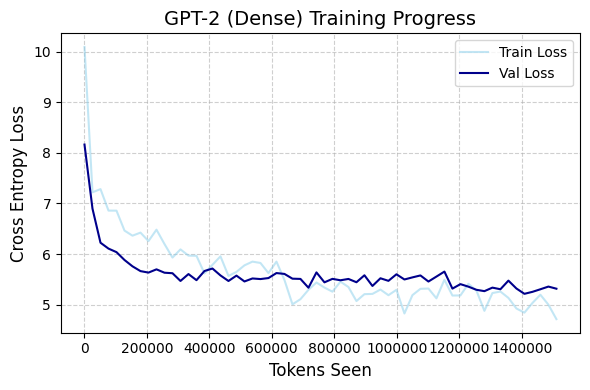

In [39]:
plot_training_results(train_losses0, val_losses0, tokens_seen0, 'GPT-2 (Dense) Training Progress')

In [40]:
import pickle

with open("/content/drive/My Drive/LLM/Data/dense_1.pkl", "wb") as f:
    pickle.dump({"train_loss": train_losses0, "val_loss": val_losses0, "tokens_seen": tokens_seen0}, f)

In [41]:
del model0
del optimizer0
import gc
gc.collect()
torch.cuda.empty_cache()

# **MoE**

In [42]:
class Expert(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(cfg['emb_size'], cfg['expert_hidden_dim']),
        GeLU(),
        nn.Linear(cfg['expert_hidden_dim'], cfg['emb_size'])
    )

  def forward(self, x):
    return self.layers(x)

class Router(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.router_layer = nn.Linear(cfg["emb_size"], cfg["n_experts"])

  def forward(self, x):
    x = self.router_layer(x)
    return x

class MoEBlock(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.topk = cfg["topk"]
    self.n_experts = cfg["n_experts"]
    self.router = Router(cfg)
    self.experts = nn.ModuleList([Expert(cfg) for _ in range(cfg["n_experts"])])

  def forward(self, x):
    batch_size, seq_len, dim = x.shape
    x_flat = x.view(batch_size * seq_len, dim) # (batch_size * seq_len = N, dim)
    N, _ = x_flat.shape

    routing_logits = self.router(x_flat)
    routing_probs = torch.softmax(routing_logits, dim=-1) # (N, n_experts)
    top_k_val, top_k_ind = torch.topk(routing_probs, self.topk, dim=-1) # both (N, topk)

    p_vector = torch.mean(routing_probs, dim=0)
    f_vector = torch.zeros(self.n_experts, device=x.device)
    ones = torch.ones(N * self.topk, device=top_k_ind.device)
    f_vector.scatter_add_(0, top_k_ind.flatten(), ones)
    f_vector = f_vector / (N * self.topk)

    lb_loss = self.n_experts * torch.dot(f_vector, p_vector) # load balancing loss

    output = torch.zeros_like(x_flat, device=x.device) # (batch_size * seq_len = N, dim)

    for e in range(self.n_experts):
      token_idx, rank_idx = torch.where(top_k_ind == e) # both token_idx -> row and rank_idx -> col; both shape (routed_tokens,)
      if token_idx.shape[0] == 0:
        continue
      expert_tokens = x_flat[token_idx] # (routed_tokens, dim)
      expert_outputs = self.experts[e](expert_tokens) # (routed_tokens, dim)
      expert_weights = top_k_val[token_idx, rank_idx].unsqueeze(-1) # (routed_tokens, 1)

      weighted_outputs = expert_weights * expert_outputs # gating

      output.scatter_add_(dim=0, # putting the weighted expert outputs back to its global index
                          index=token_idx.unsqueeze(-1).expand_as(weighted_outputs),
                          src=weighted_outputs)

    result = output.view(batch_size, seq_len, dim)

    return result, lb_loss, f_vector * self.topk # fraction of total_tokens routed to expert

In [43]:
# efficient sparse-matmul using megablocks (need to work on this)

# class Router(nn.Module):
#     def __init__(self, cfg):
#         super().__init__()
#         self.router = nn.Linear(cfg["emb_size"], cfg["n_experts"], bias=False)

#     def forward(self, x):
#         return self.router(x)


# class MoEBlock(nn.Module):
#     def __init__(self, cfg):
#         super().__init__()

#         self.emb       = cfg["emb_size"]
#         self.hidden    = cfg["expert_hidden_dim"]
#         self.n_experts = cfg["n_experts"]
#         self.topk      = cfg["topk"]
#         self.blocking  = cfg.get("block_size", 128)   # must divide both hidden and emb

#         self.router = Router(cfg)
#         self.gelu = GeLU()

#         # Weights: (n_experts * hidden, emb) — contiguous expert row blocks.
#         # No 3-D tensor, no per-expert indexing, no weight replication.
#         self.w1 = nn.Parameter(torch.empty(self.n_experts * self.hidden, self.emb))
#         self.w2 = nn.Parameter(torch.empty(self.n_experts * self.hidden, self.emb))
#         nn.init.kaiming_uniform_(self.w1, a=0.01)
#         nn.init.kaiming_uniform_(self.w2, a=0.01)

#         # Bits needed to radix-sort expert ids (used by ops.sort)
#         self.sort_end_bit = max(int(np.ceil(np.log2(self.n_experts))), 1)

#         # Bits needed to sort column indices for the sparse transpose
#         max_col_idx = (self.hidden * self.n_experts) // self.blocking
#         self.transpose_sort_end_bit = max(int(np.ceil(np.log2(max_col_idx))), 1)

#     # ------------------------------------------------------------------
#     # Build the stk.Matrix topology descriptor from padded expert bins.
#     # Mirrors ParallelDroplessMLP.topology() in dmoe.py exactly.
#     # ------------------------------------------------------------------
#     def _topology(self, x, padded_bins):
#         """
#         x           : padded token tensor, shape (padded_N, emb)
#         padded_bins : inclusive cumsum of per-expert padded token counts (E,)
#         Returns a stk.Matrix describing the block-sparse intermediate layout.
#         """
#         padded_tokens = x.size(0)
#         assert padded_tokens % self.blocking == 0
#         assert self.hidden % self.blocking == 0

#         # One block-row per expert (hidden // blocking blocks tall each)
#         blocks_per_row  = self.hidden    // self.blocking
#         block_rows      = self.n_experts * blocks_per_row

#         # BCSR row offsets — uniform stride of blocks_per_row
#         offsets = torch.arange(
#             0,
#             block_rows * blocks_per_row + 1,
#             blocks_per_row,
#             dtype=torch.int32,
#             device=x.device,
#         )

#         # Column indices: which token-blocks does each expert block touch?
#         # ops.topology returns the COO column indices for the block-sparse matrix.
#         column_indices = ops.topology(
#             padded_bins,
#             self.blocking,
#             block_rows,
#             blocks_per_row,
#         )

#         # Placeholder data — values are filled by the SDD kernel, not here.
#         data = torch.empty(
#             column_indices.numel(),
#             self.blocking,
#             self.blocking,
#             dtype=x.dtype,
#             device="meta",
#         )

#         shape = (padded_tokens, self.n_experts * self.hidden)

#         row_indices = stk.ops.row_indices(shape, data, offsets, column_indices)

#         # Build transpose index arrays for the DSD pass (w2 matmul)
#         column_indices_t, offsets_t, block_offsets_t = self._sparse_transpose(
#             shape, row_indices, column_indices, offsets
#         )

#         return stk.Matrix(
#             shape,
#             data,
#             row_indices,
#             column_indices,
#             offsets,
#             column_indices_t,
#             offsets_t,
#             block_offsets_t,
#         )

#     def _sparse_transpose(self, size, row_indices, column_indices, offsets):
#         """Mirrors ParallelDroplessMLP.sparse_transpose() in dmoe.py."""
#         block_columns = size[1] // self.blocking

#         # Sort column indices to get transposed order
#         _, gather_indices = ops.sort(column_indices, self.transpose_sort_end_bit)

#         column_indices_t = row_indices.gather(0, gather_indices.long())
#         block_offsets_t  = gather_indices.int()

#         zero = torch.zeros((1,), dtype=torch.int32, device=row_indices.device)
#         nnz_per_column = ops.histogram(column_indices, block_columns)
#         nnz_per_column = ops.inclusive_cumsum(nnz_per_column, 0)
#         if nnz_per_column.dim() == 0:
#             nnz_per_column = nnz_per_column.unsqueeze(0)
#         offsets_t = torch.cat([zero, nnz_per_column])

#         return column_indices_t, offsets_t, block_offsets_t

#     # ------------------------------------------------------------------
#     # Sort tokens and compute padded expert bins.
#     # Mirrors ParallelDroplessMLP.indices_and_padded_bins() in dmoe.py.
#     # ------------------------------------------------------------------
#     def _indices_and_padded_bins(self, top_experts):
#         top_experts = top_experts.int()
#         bin_ids, indices = ops.sort(top_experts, self.sort_end_bit)

#         tokens_per_expert = ops.histogram(bin_ids, self.n_experts)
#         bins              = ops.inclusive_cumsum(tokens_per_expert, 0)
#         bins              = bins.view(1) if not len(bins.size()) else bins

#         # Pad each expert's token count to a multiple of block size
#         padded_tpe  = ops.round_up(tokens_per_expert, self.blocking)
#         padded_bins = ops.inclusive_cumsum(padded_tpe, 0)
#         padded_bins = padded_bins.view(1) if not len(padded_bins.size()) else padded_bins

#         return indices, bin_ids, bins, padded_bins, tokens_per_expert

#     # ------------------------------------------------------------------
#     # Forward
#     # ------------------------------------------------------------------
#     def forward(self, x):
#         B, S, D = x.shape
#         x_flat  = x.view(-1, D)   # (N, D)
#         N       = x_flat.shape[0]

#         # ---- routing ------------------------------------------------
#         logits   = self.router(x_flat)                        # (N, E)
#         probs    = torch.softmax(logits, dim=-1)
#         topk_val, topk_ind = torch.topk(probs, self.topk, dim=-1)  # (N, k)

#         # Load-balancing loss
#         p_vector = probs.mean(dim=0)
#         f_vector = ops.histogram(topk_ind.flatten().int(), self.n_experts).float()
#         f_vector = f_vector / (N * self.topk)
#         lb_loss  = self.n_experts * torch.dot(f_vector, p_vector)

#         # ---- sort tokens by expert ----------------------------------
#         # Flatten top-k assignments: each token appears topk times
#         top_experts  = topk_ind.flatten()                     # (N*k,)
#         expert_weights = topk_val.flatten()                   # (N*k,)

#         indices, bin_ids, bins, padded_bins, tokens_per_expert = (
#             self._indices_and_padded_bins(top_experts)
#         )

#         # ---- padded gather (token permutation) ----------------------
#         # Groups tokens contiguously per expert, padding to block boundary.
#         # Shape: (padded_N, D)
#         x_perm = ops.padded_gather(x_flat, indices, bin_ids, bins, padded_bins, self.topk)

#         # ---- sparse topology ----------------------------------------
#         with torch.no_grad():
#             topo = self._topology(x_perm, padded_bins)

#         # ---- expert compute: SDD then DSD ---------------------------
#         # w1: (N*E_H, D)  x_perm: (padded_N, D)
#         # SDD: sparse = dense x dense  →  hidden activations (sparse, padded_N × E*H)
#         hidden = stk.ops.sdd(x_perm, self.w1.t(), topo)
#         gelu_data = self.gelu(hidden.data)
#         hidden = stk.Matrix(
#             hidden.shape,
#             gelu_data,
#             hidden.row_indices,
#             hidden.column_indices,
#             hidden.offsets,
#             hidden.column_indices_t,
#             hidden.offsets_t,
#             hidden.block_offsets_t,
#         )

#         # DSD: dense = sparse x dense  →  output (padded_N, D)
#         out = stk.ops.dsd(hidden, self.w2)

#         # ---- padded scatter (undo permutation, apply gates) ---------
#         output = ops.padded_scatter(
#             out,
#             indices,
#             bin_ids,
#             expert_weights,
#             bins,
#             padded_bins,
#             self.topk,
#         )

#         return output.view(B, S, D), lb_loss, f_vector * self.topk

In [43]:
GPT_MOE_CONFIG1 = {
    'emb_size':768,
    'total_hidden_dim': 768*4*4,
    'context_length':256,
    'vocab_size':50257,
    'num_heads':12,
    'num_layers':12,
    'n_experts':4,
    'n_shared':0,
    'topk':1,
    'drop_rate':0.1,
    'qkv_bias':False,
}

GPT_MOE_CONFIG1['expert_hidden_dim'] = GPT_MOE_CONFIG1['total_hidden_dim'] // GPT_MOE_CONFIG1['n_experts']

In [44]:
moe = MoEBlock(GPT_MOE_CONFIG1).to(device)
moe.eval()

rand_inp = torch.rand((2, 8, 768), device=device)
print(f"MoE input shape: {rand_inp.shape}")
with torch.no_grad():
  moe_logits, temp_aux_loss, f_vector_plot = moe(rand_inp)

print(f"MoE output shape: {moe_logits.shape}")
print(f"MoE Load Balancing Loss: {temp_aux_loss}")
print(f"Token distribution across experts: {f_vector_plot}")

MoE input shape: torch.Size([2, 8, 768])
MoE output shape: torch.Size([2, 8, 768])
MoE Load Balancing Loss: 1.430974006652832
Token distribution across experts: tensor([0.8750, 0.0000, 0.0000, 0.1250], device='cuda:0')


In [45]:
del moe
import gc
gc.collect()
torch.cuda.empty_cache()

In [46]:
class TransformerMoEBlock(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.mha = MultiHeadAttention(cfg['emb_size'], cfg['emb_size'], cfg['context_length'], cfg['drop_rate'], cfg['num_heads'], qkv_bias=cfg['qkv_bias'])
    self.layer_norm1 = LayerNorm(cfg['emb_size'])
    self.layer_norm2 = LayerNorm(cfg['emb_size'])
    self.moe = MoEBlock(cfg)
    self.dropout = nn.Dropout(cfg['drop_rate'])

  def forward(self, x):
    shortcut = x
    x = self.layer_norm1(x)
    x = self.mha(x)
    x = self.dropout(x)
    x = x + shortcut

    shortcut = x
    x = self.layer_norm2(x)
    x, lb_loss, f_vector_plot = self.moe(x)
    x = self.dropout(x)
    x = x + shortcut

    return x, lb_loss, f_vector_plot

In [47]:
class GPTMoEModel(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.token_emb_layer = nn.Embedding(cfg['vocab_size'], cfg['emb_size'])
    self.pos_emb_layer = nn.Embedding(cfg['context_length'], cfg['emb_size'])
    self.dropout_layer = nn.Dropout(cfg['drop_rate'])
    self.trf_blocks = nn.ModuleList(
        [TransformerMoEBlock(cfg) for _ in range(cfg['num_layers'])]
    )
    self.final_norm = LayerNorm(cfg['emb_size'])
    self.output_layer = nn.Linear(cfg['emb_size'], cfg['vocab_size'], bias=False)

  def forward(self, inp_tokens):
    batch_size, num_tokens = inp_tokens.shape
    token_emb = self.token_emb_layer(inp_tokens)
    pos_emb = self.pos_emb_layer(
        torch.arange(num_tokens, device=inp_tokens.device)
    )
    x = token_emb + pos_emb
    x = self.dropout_layer(x)
    total_lb_loss = 0.
    for i, block in enumerate(self.trf_blocks):
      x, lb_loss, f_vector_plot = block(x)
      total_lb_loss += lb_loss
      if i==0:
        f_vector_plot_ = f_vector_plot
    x = self.final_norm(x)
    logits = self.output_layer(x)

    return logits, total_lb_loss, f_vector_plot_

## Without Load Balancing Loss - 4 Experts and k=1

In [48]:
import time

torch.manual_seed(123)
model1 = GPTMoEModel(GPT_MOE_CONFIG1).to(device)
param_counts1 = sum([p.numel() for p in model1.parameters() if p.requires_grad])
total_param_counts1 = sum([p.numel() for p in model1.parameters()])
print(f"Total Parameters: {total_param_counts1}")
print(f"Trainabe Parameters: {param_counts1}")
optimizer1 = torch.optim.AdamW(model1.parameters(), lr=0.0004, weight_decay=0.1)

t1 = time.time()
train_losses1, val_losses1, tokens_seen1, fract_tokens_per_expert_list1 = train_model_without_load_bal(model1, train_loader, val_loader, device, optimizer1, epochs=2, eval_freq=50, eval_iter=5, start_context='Blazing stars, with the great blurry bluish', tokenizer=tokenizer)
t2 = time.time()

print(f"Training time: {t2-t1}s")

Total Parameters: 332464176
Trainabe Parameters: 332464176
Train loss after epoch 0 (Step: 0): 10.490
Val loss after epoch 0 (Step: 0): 10.608
Number of tokens seen after epoch 0 (Step: 0): 512
Train loss after epoch 0 (Step: 50): 7.245
Val loss after epoch 0 (Step: 50): 6.820
Number of tokens seen after epoch 0 (Step: 50): 26112
Train loss after epoch 0 (Step: 100): 7.085
Val loss after epoch 0 (Step: 100): 6.399
Number of tokens seen after epoch 0 (Step: 100): 51712
Train loss after epoch 0 (Step: 150): 6.502
Val loss after epoch 0 (Step: 150): 6.052
Number of tokens seen after epoch 0 (Step: 150): 77312
Train loss after epoch 0 (Step: 200): 6.523
Val loss after epoch 0 (Step: 200): 6.111
Number of tokens seen after epoch 0 (Step: 200): 102912
Train loss after epoch 0 (Step: 250): 6.488
Val loss after epoch 0 (Step: 250): 6.093
Number of tokens seen after epoch 0 (Step: 250): 128512
Train loss after epoch 0 (Step: 300): 6.431
Val loss after epoch 0 (Step: 300): 6.079
Number of tokens

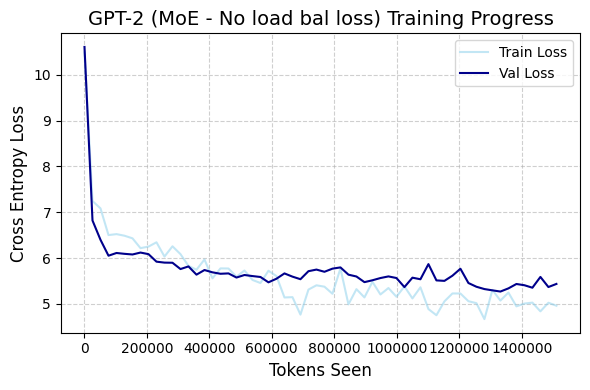

In [49]:
plot_training_results(train_losses1, val_losses1, tokens_seen1, 'GPT-2 (MoE - No load bal loss) Training Progress')

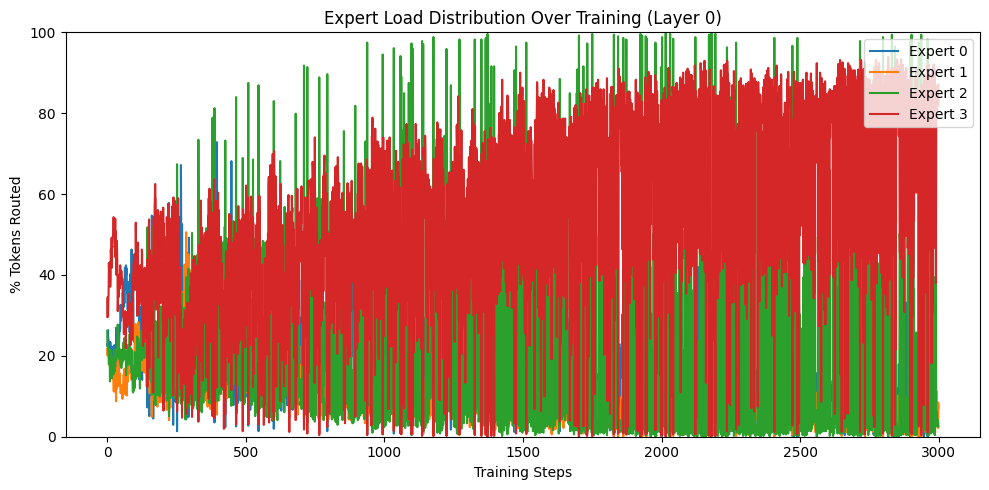

In [113]:
plot_expert_load(fract_tokens_per_expert_list1, smooth_window=0)

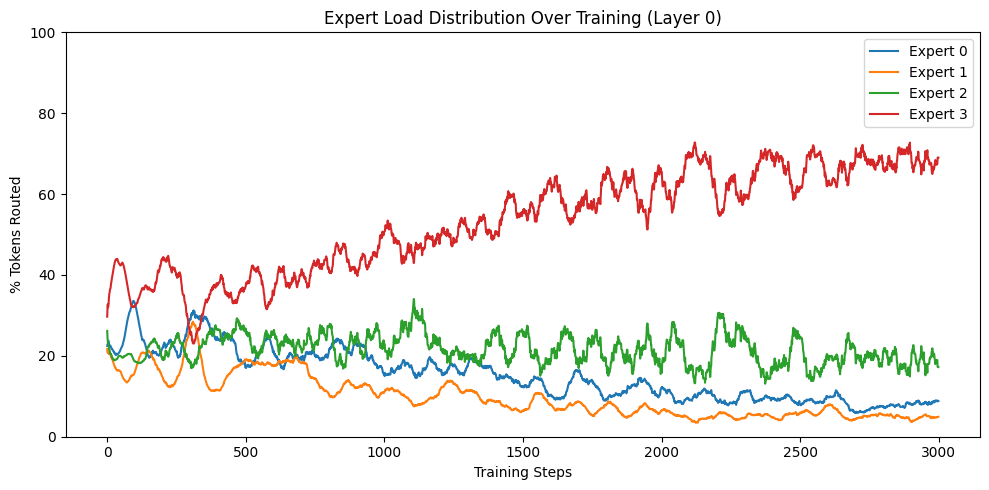

In [114]:
plot_expert_load(fract_tokens_per_expert_list1, smooth_window=50)

In [52]:
import pickle

with open("/content/drive/My Drive/LLM/Data/moe_no_bal_e4_k1.pkl", "wb") as f:
    pickle.dump({"train_loss": train_losses1, "val_loss": val_losses1, "tokens_seen": tokens_seen1}, f)

In [53]:
del model1
del optimizer1
import gc
gc.collect()
torch.cuda.empty_cache()

## With Load Balancing Loss - 4 Experts and k=1

In [56]:
import time

torch.manual_seed(123)
model2 = GPTMoEModel(GPT_MOE_CONFIG1).to(device)
param_counts2 = sum([p.numel() for p in model2.parameters() if p.requires_grad])
total_param_counts2 = sum([p.numel() for p in model2.parameters()])
print(f"Total Parameters: {total_param_counts2}")
print(f"Trainabe Parameters: {param_counts2}")
optimizer2 = torch.optim.AdamW(model2.parameters(), lr=0.0004, weight_decay=0.1)

t3 = time.time()
train_losses2, val_losses2, tokens_seen2, fract_tokens_per_expert_list2 = train_model_with_load_bal(model2, train_loader, val_loader, device, optimizer2, epochs=2, eval_freq=50, eval_iter=5, start_context='Blazing stars, with the great blurry bluish', tokenizer=tokenizer)
t4 = time.time()

print(f"Training time: {t4-t3}s")

Total Parameters: 332464176
Trainabe Parameters: 332464176
Train loss after epoch 0 (Step: 0): 10.492
Val loss after epoch 0 (Step: 0): 10.609
Number of tokens seen after epoch 0 (Step: 0): 512
Train loss after epoch 0 (Step: 50): 7.203
Val loss after epoch 0 (Step: 50): 6.491
Number of tokens seen after epoch 0 (Step: 50): 26112
Train loss after epoch 0 (Step: 100): 6.949
Val loss after epoch 0 (Step: 100): 6.432
Number of tokens seen after epoch 0 (Step: 100): 51712
Train loss after epoch 0 (Step: 150): 6.411
Val loss after epoch 0 (Step: 150): 6.024
Number of tokens seen after epoch 0 (Step: 150): 77312
Train loss after epoch 0 (Step: 200): 6.534
Val loss after epoch 0 (Step: 200): 6.175
Number of tokens seen after epoch 0 (Step: 200): 102912
Train loss after epoch 0 (Step: 250): 6.413
Val loss after epoch 0 (Step: 250): 6.006
Number of tokens seen after epoch 0 (Step: 250): 128512
Train loss after epoch 0 (Step: 300): 6.336
Val loss after epoch 0 (Step: 300): 5.968
Number of tokens

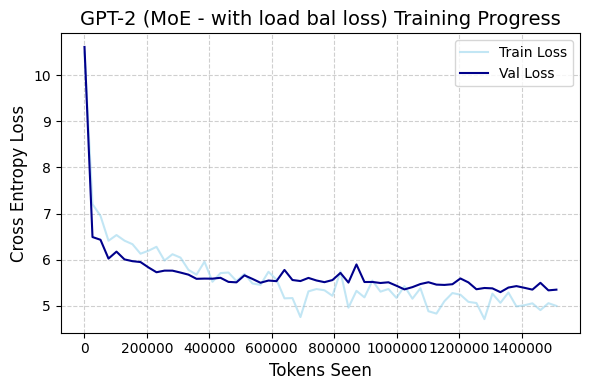

In [57]:
plot_training_results(train_losses2, val_losses2, tokens_seen2, 'GPT-2 (MoE - with load bal loss) Training Progress')

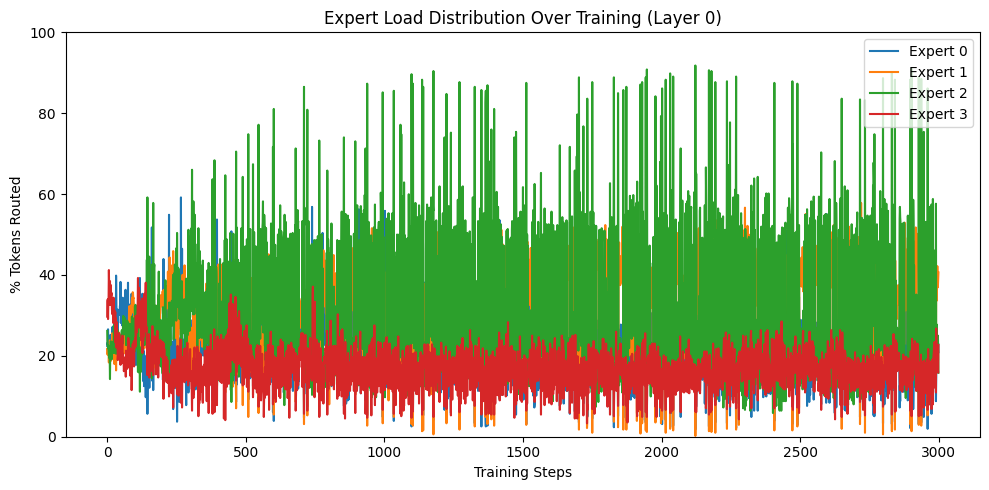

In [116]:
plot_expert_load(fract_tokens_per_expert_list2, smooth_window=0)

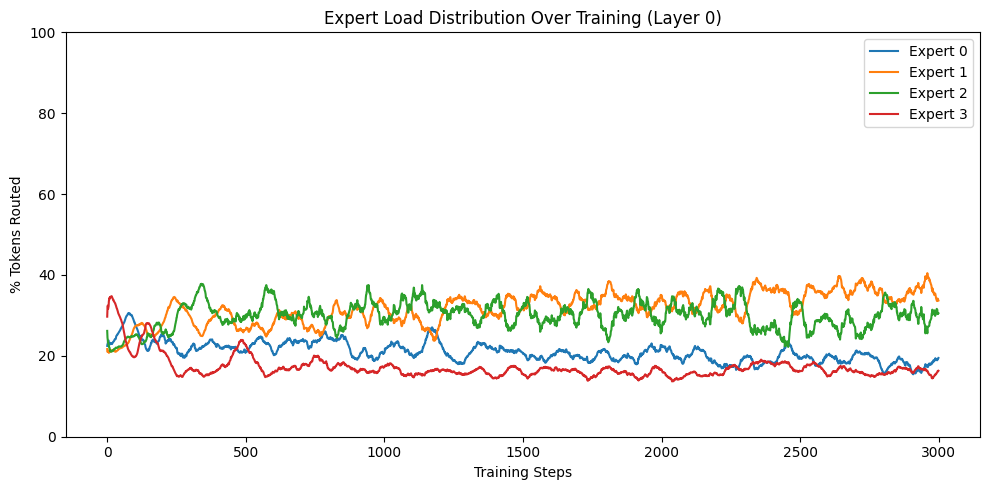

In [115]:
plot_expert_load(fract_tokens_per_expert_list2, smooth_window=50)

In [65]:
import pickle

with open("/content/drive/My Drive/LLM/Data/moe_with_bal_e4_k1.pkl", "wb") as f:
    pickle.dump({"train_loss": train_losses2, "val_loss": val_losses2, "tokens_seen": tokens_seen2}, f)

In [66]:
del model2
del optimizer2
import gc
gc.collect()
torch.cuda.empty_cache()

## With Load Balancing Loss - 8 Experts and k=2

---



In [67]:
GPT_MOE_CONFIG2 = {
    'emb_size':768,
    'total_hidden_dim': 768*4*4,
    'context_length':1024,
    'vocab_size':50257,
    'num_heads':12,
    'num_layers':12,
    'n_experts':8,
    'n_shared':0,
    'topk':2,
    'drop_rate':0.1,
    'qkv_bias':False,
}

GPT_MOE_CONFIG2['expert_hidden_dim'] = GPT_MOE_CONFIG2['total_hidden_dim'] // GPT_MOE_CONFIG2['n_experts']

In [68]:
import time

torch.manual_seed(123)
model3 = GPTMoEModel(GPT_MOE_CONFIG2).to(device)
param_counts3 = sum([p.numel() for p in model3.parameters() if p.requires_grad])
total_param_counts3 = sum([p.numel() for p in model3.parameters()])
print(f"Total Parameters: {total_param_counts3}")
print(f"Trainabe Parameters: {param_counts3}")
optimizer3 = torch.optim.AdamW(model3.parameters(), lr=0.0004, weight_decay=0.1)

t5 = time.time()
train_losses3, val_losses3, tokens_seen3, fract_tokens_per_expert_list3 = train_model_with_load_bal(model3, train_loader, val_loader, device, optimizer3, epochs=2, eval_freq=50, eval_iter=5, start_context='Blazing stars, with the great blurry bluish', tokenizer=tokenizer)
t6 = time.time()

print(f"Training time: {t6-t5}s")

Total Parameters: 333127776
Trainabe Parameters: 333127776
Train loss after epoch 0 (Step: 0): 10.573
Val loss after epoch 0 (Step: 0): 10.686
Number of tokens seen after epoch 0 (Step: 0): 512
Train loss after epoch 0 (Step: 50): 6.997
Val loss after epoch 0 (Step: 50): 6.269
Number of tokens seen after epoch 0 (Step: 50): 26112
Train loss after epoch 0 (Step: 100): 6.801
Val loss after epoch 0 (Step: 100): 6.433
Number of tokens seen after epoch 0 (Step: 100): 51712
Train loss after epoch 0 (Step: 150): 6.790
Val loss after epoch 0 (Step: 150): 6.097
Number of tokens seen after epoch 0 (Step: 150): 77312
Train loss after epoch 0 (Step: 200): 6.247
Val loss after epoch 0 (Step: 200): 5.997
Number of tokens seen after epoch 0 (Step: 200): 102912
Train loss after epoch 0 (Step: 250): 5.990
Val loss after epoch 0 (Step: 250): 5.898
Number of tokens seen after epoch 0 (Step: 250): 128512
Train loss after epoch 0 (Step: 300): 6.382
Val loss after epoch 0 (Step: 300): 5.923
Number of tokens

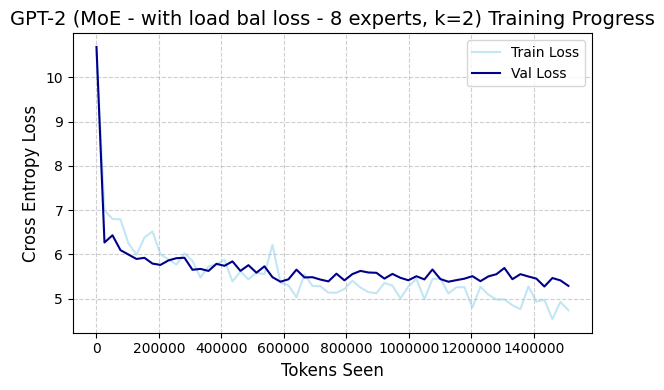

In [69]:
plot_training_results(train_losses3, val_losses3, tokens_seen3, 'GPT-2 (MoE - with load bal loss - 8 experts, k=2) Training Progress')

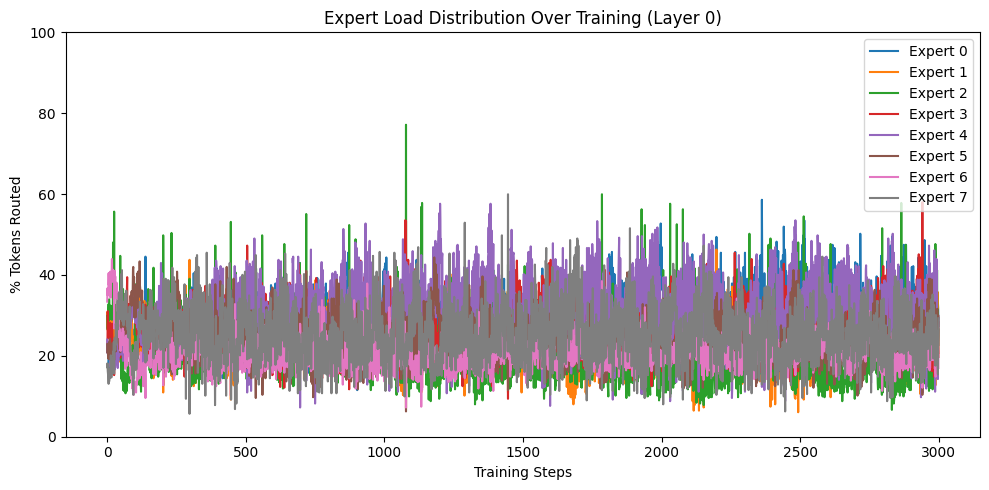

In [117]:
plot_expert_load(fract_tokens_per_expert_list3, smooth_window=0)

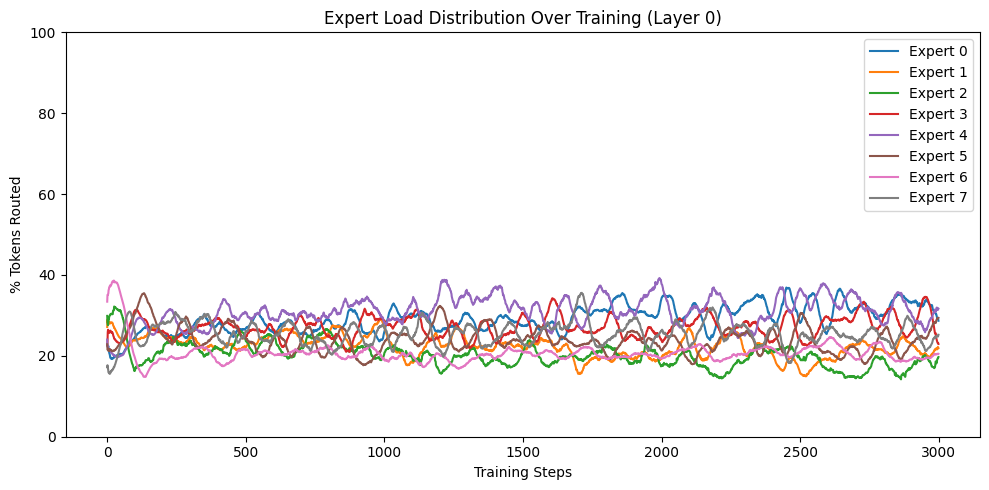

In [118]:
plot_expert_load(fract_tokens_per_expert_list3, smooth_window=50)

In [72]:
import pickle

with open("/content/drive/My Drive/LLM/Data/moe_e8_k2.pkl", "wb") as f:
    pickle.dump({"train_loss": train_losses3, "val_loss": val_losses3, "tokens_seen": tokens_seen3}, f)

In [73]:
del model3
del optimizer3
import gc
gc.collect()
torch.cuda.empty_cache()

## With Load Balancing Loss - 16 Experts and k=4

In [74]:
GPT_MOE_CONFIG3 = {
    'emb_size':768,
    'total_hidden_dim': 768*4*4,
    'context_length':1024,
    'vocab_size':50257,
    'num_heads':12,
    'num_layers':12,
    'n_experts':16,
    'n_shared':0,
    'topk':4,
    'drop_rate':0.1,
    'qkv_bias':False,
}

GPT_MOE_CONFIG3['expert_hidden_dim'] = GPT_MOE_CONFIG3['total_hidden_dim'] // GPT_MOE_CONFIG3['n_experts']

In [75]:
import time

torch.manual_seed(123)
model4 = GPTMoEModel(GPT_MOE_CONFIG3).to(device)
param_counts4 = sum([p.numel() for p in model4.parameters() if p.requires_grad])
total_param_counts4 = sum([p.numel() for p in model4.parameters()])
print(f"Total Parameters: {total_param_counts4}")
print(f"Trainabe Parameters: {param_counts4}")
optimizer4 = torch.optim.AdamW(model4.parameters(), lr=0.0004, weight_decay=0.1)

t7 = time.time()
train_losses4, val_losses4, tokens_seen4, fract_tokens_per_expert_list4 = train_model_with_load_bal(model4, train_loader, val_loader, device, optimizer4, epochs=2, eval_freq=50, eval_iter=5, start_context='Blazing stars, with the great blurry bluish', tokenizer=tokenizer)
t8 = time.time()

print(f"Training time: {t8-t7}s")

Total Parameters: 333275328
Trainabe Parameters: 333275328
Train loss after epoch 0 (Step: 0): 10.636
Val loss after epoch 0 (Step: 0): 10.758
Number of tokens seen after epoch 0 (Step: 0): 512
Train loss after epoch 0 (Step: 50): 7.326
Val loss after epoch 0 (Step: 50): 7.204
Number of tokens seen after epoch 0 (Step: 50): 26112
Train loss after epoch 0 (Step: 100): 6.711
Val loss after epoch 0 (Step: 100): 6.216
Number of tokens seen after epoch 0 (Step: 100): 51712
Train loss after epoch 0 (Step: 150): 6.766
Val loss after epoch 0 (Step: 150): 5.979
Number of tokens seen after epoch 0 (Step: 150): 77312
Train loss after epoch 0 (Step: 200): 6.171
Val loss after epoch 0 (Step: 200): 5.889
Number of tokens seen after epoch 0 (Step: 200): 102912
Train loss after epoch 0 (Step: 250): 6.431
Val loss after epoch 0 (Step: 250): 5.775
Number of tokens seen after epoch 0 (Step: 250): 128512
Train loss after epoch 0 (Step: 300): 5.923
Val loss after epoch 0 (Step: 300): 6.015
Number of tokens

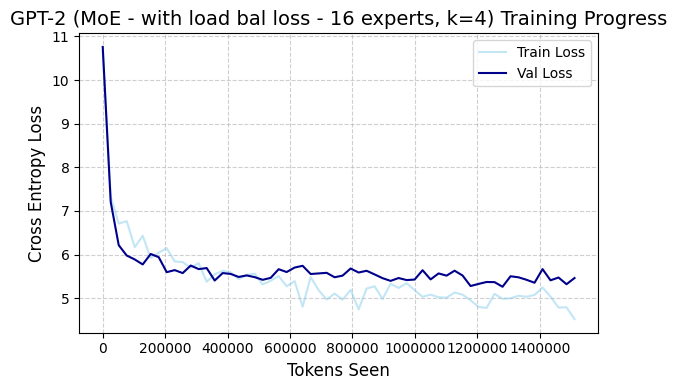

In [76]:
plot_training_results(train_losses4, val_losses4, tokens_seen4, 'GPT-2 (MoE - with load bal loss - 16 experts, k=4) Training Progress')

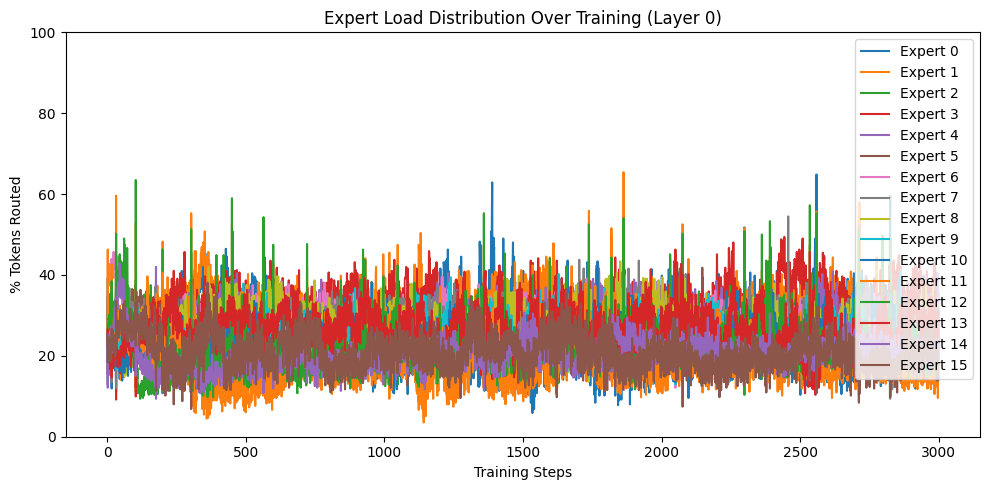

In [119]:
plot_expert_load(fract_tokens_per_expert_list4, smooth_window=0)

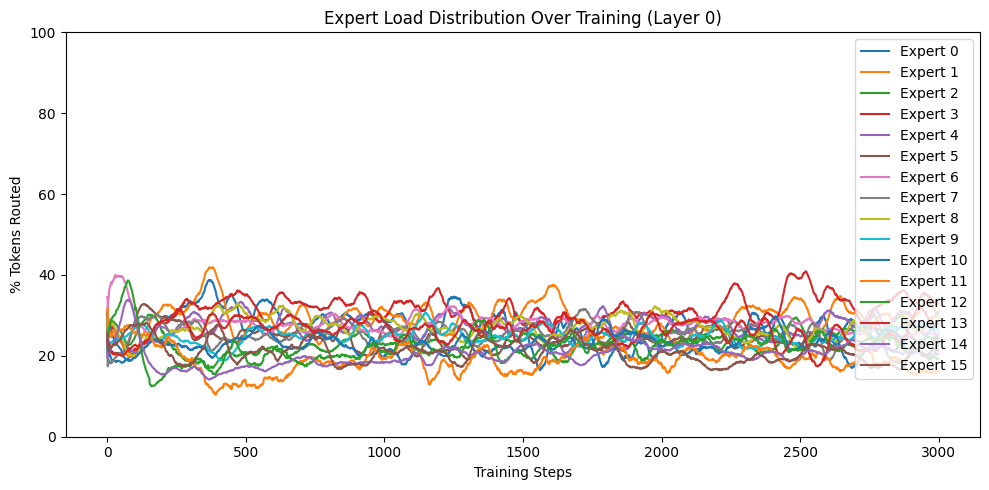

In [120]:
plot_expert_load(fract_tokens_per_expert_list4, smooth_window=50)

In [79]:
import pickle

with open("/content/drive/My Drive/LLM/Data/moe_e16_k4.pkl", "wb") as f:
    pickle.dump({"train_loss": train_losses4, "val_loss": val_losses4, "tokens_seen": tokens_seen4}, f)

In [80]:
del model4
del optimizer4
import gc
gc.collect()
torch.cuda.empty_cache()

## With Load Balancing Loss - 32 Experts and k=8

In [84]:
GPT_MOE_CONFIG4 = {
    'emb_size':768,
    'total_hidden_dim': 768*4*4,
    'context_length':1024,
    'vocab_size':50257,
    'num_heads':12,
    'num_layers':12,
    'n_experts':32,
    'n_shared':0,
    'topk':8,
    'drop_rate':0.1,
    'qkv_bias':False,
}

GPT_MOE_CONFIG4['expert_hidden_dim'] = GPT_MOE_CONFIG4['total_hidden_dim'] // GPT_MOE_CONFIG4['n_experts']

In [85]:
import time

torch.manual_seed(123)
model5 = GPTMoEModel(GPT_MOE_CONFIG4).to(device)
param_counts5 = sum([p.numel() for p in model5.parameters() if p.requires_grad])
total_param_counts5 = sum([p.numel() for p in model5.parameters()])
print(f"Total Parameters: {total_param_counts5}")
print(f"Trainabe Parameters: {param_counts5}")
optimizer5 = torch.optim.AdamW(model5.parameters(), lr=0.0004, weight_decay=0.1)

t9 = time.time()
train_losses5, val_losses5, tokens_seen5, fract_tokens_per_expert_list5 = train_model_with_load_bal(model5, train_loader, val_loader, device, optimizer5, epochs=2, eval_freq=50, eval_iter=5, start_context='Blazing stars, with the great blurry bluish', tokenizer=tokenizer)
t10 = time.time()

print(f"Training time: {t10-t9}s")

Total Parameters: 333570432
Trainabe Parameters: 333570432
Train loss after epoch 0 (Step: 0): 10.564
Val loss after epoch 0 (Step: 0): 10.494
Number of tokens seen after epoch 0 (Step: 0): 512
Train loss after epoch 0 (Step: 50): 7.312
Val loss after epoch 0 (Step: 50): 6.862
Number of tokens seen after epoch 0 (Step: 50): 26112
Train loss after epoch 0 (Step: 100): 7.184
Val loss after epoch 0 (Step: 100): 6.269
Number of tokens seen after epoch 0 (Step: 100): 51712
Train loss after epoch 0 (Step: 150): 6.965
Val loss after epoch 0 (Step: 150): 6.110
Number of tokens seen after epoch 0 (Step: 150): 77312
Train loss after epoch 0 (Step: 200): 6.373
Val loss after epoch 0 (Step: 200): 5.997
Number of tokens seen after epoch 0 (Step: 200): 102912
Train loss after epoch 0 (Step: 250): 6.442
Val loss after epoch 0 (Step: 250): 5.960
Number of tokens seen after epoch 0 (Step: 250): 128512
Train loss after epoch 0 (Step: 300): 6.418
Val loss after epoch 0 (Step: 300): 5.934
Number of tokens

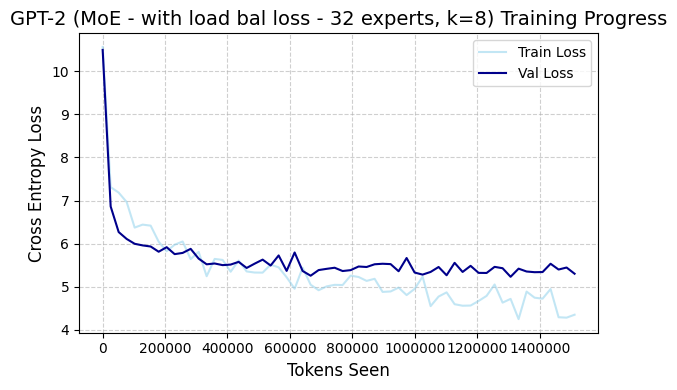

In [86]:
plot_training_results(train_losses5, val_losses5, tokens_seen5, 'GPT-2 (MoE - with load bal loss - 32 experts, k=8) Training Progress')

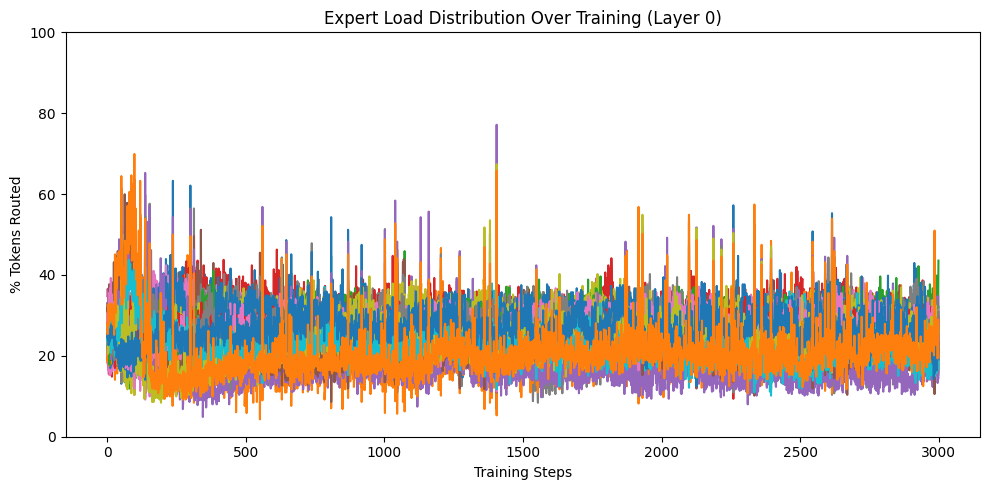

In [122]:
plot_expert_load(fract_tokens_per_expert_list5, smooth_window=0, legend=False)

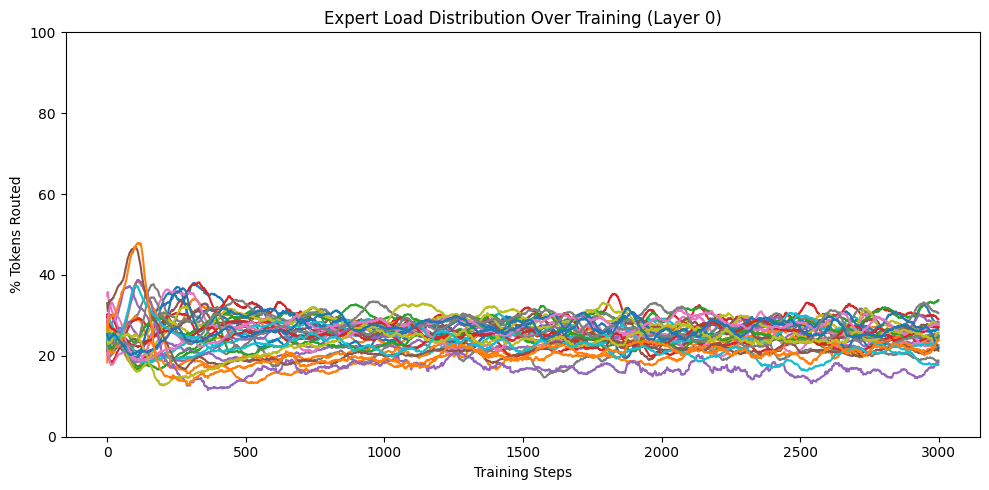

In [123]:
plot_expert_load(fract_tokens_per_expert_list5, smooth_window=50, legend=False)

In [89]:
import pickle

with open("/content/drive/My Drive/LLM/Data/moe_e32_k8.pkl", "wb") as f:
    pickle.dump({"train_loss": train_losses5, "val_loss": val_losses5, "tokens_seen": tokens_seen5}, f)

In [93]:
del model5
del optimizer5
import gc
gc.collect()
torch.cuda.empty_cache()

# Comparison

In [129]:
import pandas as pd

def plot_val_loss(experiments: dict, smooth_window=None):
    """
    ARGS
    experiments : {
        "dense": {"tokens": [...], "val_loss": [...]},
        "moe_4e": {"tokens": [...], "val_loss": [...]},
        ...
    }
    smooth_window : int or None
    """

    plt.figure(figsize=(10, 5))
    for name, data in experiments.items():
        tokens = data["tokens_seen"]
        y = [vl.cpu() for vl in data["val_loss"]]
        if smooth_window:
            y = pd.Series(y).rolling(window=smooth_window, min_periods=1).mean()
        plt.plot(tokens, y, label=name)

    plt.xlabel("Tokens Seen")
    plt.ylabel("Val Loss")
    plt.title("Validation Loss vs Tokens Seen")
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

In [95]:
exp_losses = {}

with open("/content/drive/My Drive/LLM/Data/dense_1.pkl", "rb") as f:
  dense_data = pickle.load(f)
  exp_losses["dense"] = dense_data

with open("/content/drive/My Drive/LLM/Data/moe_no_bal_e4_k1.pkl", "rb") as f:
  moe_no_bal_e4_k1 = pickle.load(f)
  exp_losses["moe_no_bal_e4_k1"] = moe_no_bal_e4_k1

with open("/content/drive/My Drive/LLM/Data/moe_with_bal_e4_k1.pkl", "rb") as f:
  moe_with_bal_e4_k1 = pickle.load(f)
  exp_losses["moe_with_bal_e4_k1"] = moe_with_bal_e4_k1

with open("/content/drive/My Drive/LLM/Data/moe_e8_k2.pkl", "rb") as f:
  moe_e8_k2 = pickle.load(f)
  exp_losses["moe_e8_k2"] = moe_e8_k2

with open("/content/drive/My Drive/LLM/Data/moe_e16_k4.pkl", "rb") as f:
  moe_e16_k4 = pickle.load(f)
  exp_losses["moe_e16_k4"] = moe_e16_k4

with open("/content/drive/My Drive/LLM/Data/moe_e32_k8.pkl", "rb") as f:
  moe_e32_k8 = pickle.load(f)
  exp_losses["moe_e32_k8"] = moe_e32_k8

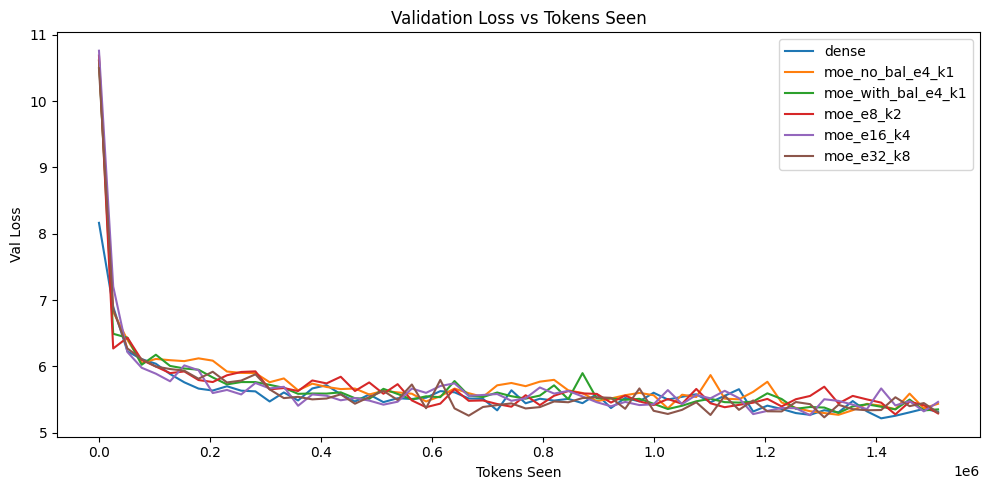

In [130]:
plot_val_loss(exp_losses)

In [143]:
def plot_perplexity(experiments: dict, smooth_window=None):
    """
    ARGS
    experiments : {
        "dense": {"tokens": [...], "val_loss": [...]},
        ...
    }
    smooth_window : int or None
    """
    plt.figure(figsize=(10, 5))
    for name, data in experiments.items():
        tokens = data["tokens_seen"]
        val_loss = [vl.cpu() for vl in data["val_loss"]]
        y = pd.Series(np.exp(val_loss))
        if smooth_window:
            y = y.rolling(window=smooth_window, min_periods=1).mean()
        plt.plot(tokens, y, label=name, linewidth=2)

    plt.xlabel("Tokens Seen")
    plt.ylabel("Perplexity")
    plt.title("Perplexity vs Tokens Seen")
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

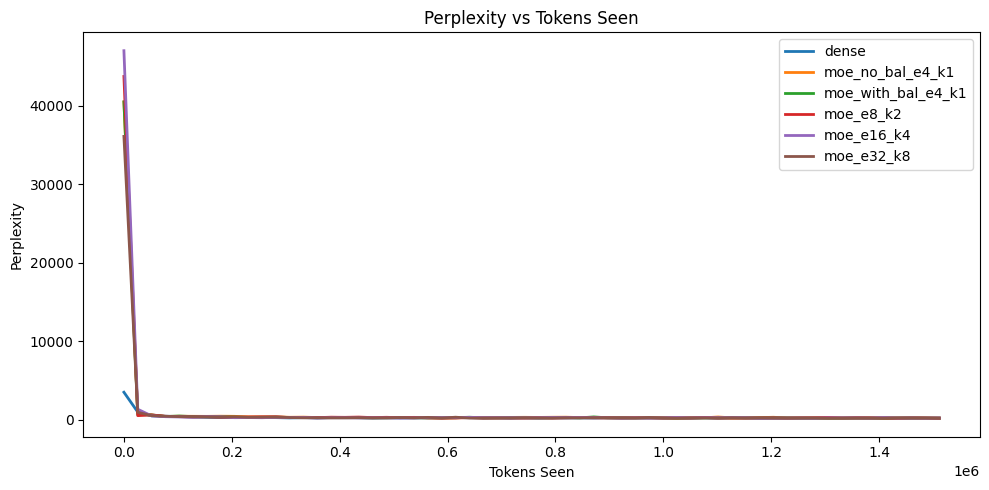

In [144]:
plot_perplexity(exp_losses)

In [133]:
def plot_loss_gap(experiments: dict, baseline: str, smooth_window=None):
    """
    ARGS
    experiments : {
        "dense": {"tokens": [...], "val_loss": [...]},
        ...
    }
    baseline      : key in experiments to use as the reference (e.g. "dense")
    smooth_window : int or None
    """
    baseline_loss = np.array([vl.cpu() for vl in experiments[baseline]["val_loss"]])
    baseline_tokens = experiments[baseline]["tokens_seen"]

    plt.figure(figsize=(10, 5))
    for name, data in experiments.items():
        if name == baseline:
            continue
        gap = pd.Series(np.array([vl.cpu() for vl in data["val_loss"]]) - baseline_loss)
        if smooth_window:
            gap = gap.rolling(window=smooth_window, min_periods=1).mean()
        plt.plot(baseline_tokens, gap, label=name, linewidth=2)

    plt.axhline(0, color="black", linestyle="--", linewidth=1, label=baseline + " (baseline)")
    plt.xlabel("Tokens Seen")
    plt.ylabel("Val Loss Gap (model - baseline)")
    plt.title(f"Loss Gap vs {baseline}")
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

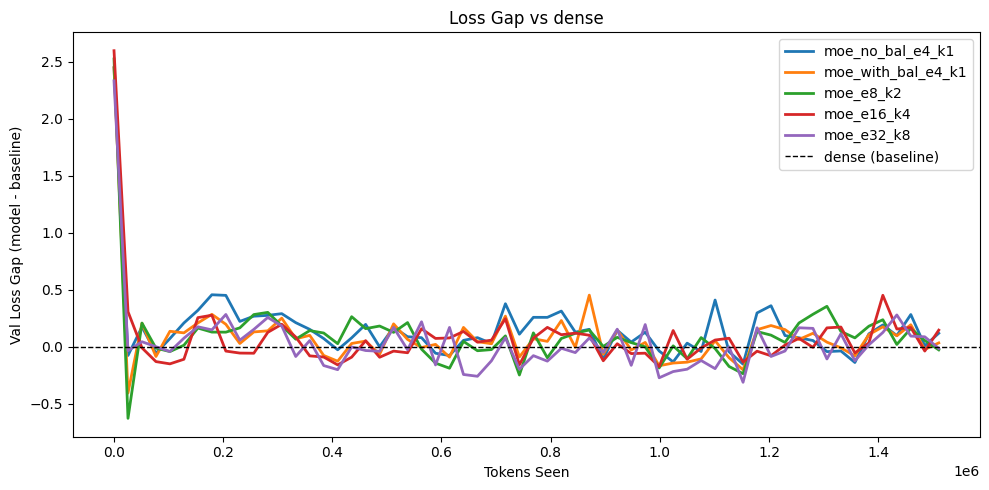

In [134]:
plot_loss_gap(exp_losses, "dense")